In [1]:
import pandas as pd

df = pd.read_csv(
    "twitter_training.csv",
    encoding="latin-1",
    header=None
)

In [2]:
df.shape

(74682, 4)

In [3]:
df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df.columns

Index([0, 1, 2, 3], dtype='int64')

In [5]:
df.columns = ["id", "entity", "sentiment", "text"]

print(df.columns)
print(df.shape)

Index(['id', 'entity', 'sentiment', 'text'], dtype='str')
(74682, 4)


In [6]:
print(df["sentiment"].value_counts())

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [7]:
print(df.isnull().sum())

id             0
entity         0
sentiment      0
text         686
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2700


In [9]:
# Drop duplicate rows
df = df.drop_duplicates()

In [10]:
# Remove rows with missing tweet text
df = df.dropna(subset=["text"])

In [11]:
# Filter out 'Irrelevant' category
df = df[df["sentiment"] != "Irrelevant"]

# Reset index
df = df.reset_index(drop=True)

In [12]:
print("Unique sentiments:")
print(df["sentiment"].unique())

Unique sentiments:
<ArrowStringArray>
['Positive', 'Neutral', 'Negative']
Length: 3, dtype: str


In [13]:
df.shape

(59119, 4)

In [14]:
print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Shape after cleaning: (59119, 4)

Missing values:
id           0
entity       0
sentiment    0
text         0
dtype: int64

Sentiment distribution:
sentiment
Negative    21698
Positive    19713
Neutral     17708
Name: count, dtype: int64


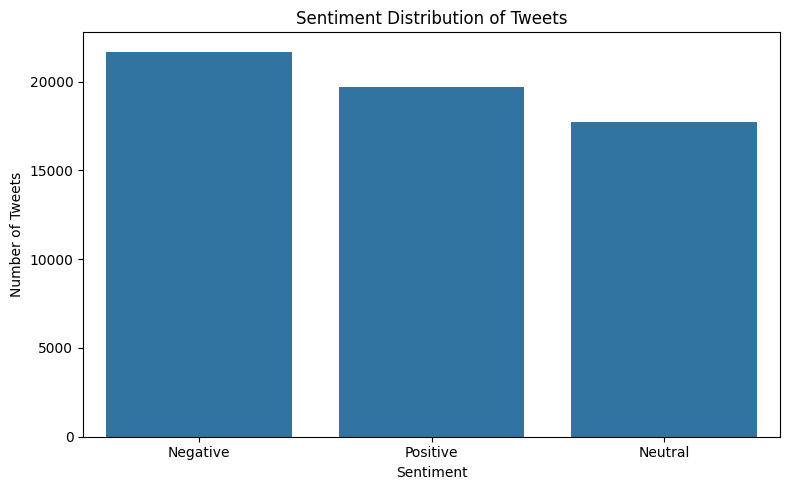

In [15]:
# Visualizing sentiment distribution

import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution of Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

In [16]:
print(sentiment_counts)

sentiment
Negative    21698
Positive    19713
Neutral     17708
Name: count, dtype: int64


In [17]:
# Installing/import NLTK resources
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SRIDHAR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SRIDHAR\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\SRIDHAR\AppData\Roaming\nltk_data...


In [18]:
# Creating the text-cleaning function

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

In [19]:
# Applying it to the dataset

df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head(10))

                                                text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   
5  im getting into borderlands and i can murder y...   
6  So I spent a few hours making something for fu...   
7  So I spent a couple of hours doing something f...   
8  So I spent a few hours doing something for fun...   
9  So I spent a few hours making something for fu...   

                                          clean_text  
0                       im getting borderland murder  
1                                 coming border kill  
2                         im getting borderland kill  
3                        im coming borderland murder  
4                       im getting borderland murder  
5                       im getting borderland murder 

In [20]:
# Checking for empty cleaned tweets

empty_cleaned = (df["clean_text"].str.strip() == "").sum()

print("Empty cleaned tweets:", empty_cleaned)

Empty cleaned tweets: 1405


In [21]:
'''
These are tweets that became empty after removing URLs, mentions, punctuation, stopwords, etc. 
As i need to remove them before model training, because TF-IDF cannot learn useful features from empty text.
'''

'\nThese are tweets that became empty after removing URLs, mentions, punctuation, stopwords, etc. \nAs i need to remove them before model training, because TF-IDF cannot learn useful features from empty text.\n'

In [22]:
# Removing empty cleaned tweets

# Remove tweets with empty cleaned text
df = df[df["clean_text"].str.strip() != ""]

# Reset index
df = df.reset_index(drop=True)

print("Shape after removing empty tweets:", df.shape)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Shape after removing empty tweets: (57714, 5)

Sentiment distribution:
sentiment
Negative    21245
Positive    19220
Neutral     17249
Name: count, dtype: int64


In [23]:
print(df[["sentiment", "clean_text"]].head(10))
print("\nMissing values:")
print(df[["sentiment", "clean_text"]].isnull().sum())

  sentiment                                         clean_text
0  Positive                       im getting borderland murder
1  Positive                                 coming border kill
2  Positive                         im getting borderland kill
3  Positive                        im coming borderland murder
4  Positive                       im getting borderland murder
5  Positive                       im getting borderland murder
6  Positive  spent hour making something fun dont know huge...
7  Positive  spent couple hour something fun dont know im h...
8  Positive  spent hour something fun dont know im huge bor...
9  Positive  spent hour making something fun dont know huge...

Missing values:
sentiment     0
clean_text    0
dtype: int64


In [24]:
# Preparing X and y

X = df["clean_text"]
y = df["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (57714,)
y shape: (57714,)


In [25]:
#  Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (46171,)
X_test: (11543,)
y_train: (46171,)
y_test: (11543,)


In [26]:
###   TF-IDF Vectorization 
# - Now we convert the cleaned tweets into numerical features that the machine-learning model can understand.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train TF-IDF shape:", X_train_tfidf.shape)
print("X_test TF-IDF shape:", X_test_tfidf.shape)

X_train TF-IDF shape: (46171, 10000)
X_test TF-IDF shape: (11543, 10000)


In [28]:
'''
max_features=10000 → keeps the most useful 10,000 features and avoids excessive memory usage.
ngram_range=(1, 2) → considers both individual words and two-word combinations.
min_df=2 → ignores words appearing only once.
max_df=0.95 → ignores extremely common terms.
fit_transform() is used only on training data.
transform() is used on test data so there is no data leakage.
'''

'\nmax_features=10000 → keeps the most useful 10,000 features and avoids excessive memory usage.\nngram_range=(1, 2) → considers both individual words and two-word combinations.\nmin_df=2 → ignores words appearing only once.\nmax_df=0.95 → ignores extremely common terms.\nfit_transform() is used only on training data.\ntransform() is used on test data so there is no data leakage.\n'

In [29]:
# Training Logistic Regression Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [30]:
# Making Predictions

y_pred = model.predict(X_test_tfidf)

print("Predictions completed.")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed.
First 20 predictions:
['Neutral' 'Neutral' 'Positive' 'Negative' 'Positive' 'Positive'
 'Negative' 'Positive' 'Neutral' 'Neutral' 'Positive' 'Neutral' 'Positive'
 'Neutral' 'Negative' 'Positive' 'Neutral' 'Positive' 'Positive'
 'Negative']


In [31]:
# Basic Evaluation

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.792341678939617


In [32]:
# Classification Report 

from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print("===== Classification Report =====")
print(report)


===== Classification Report =====
              precision    recall  f1-score   support

    Negative       0.81      0.84      0.82      4249
     Neutral       0.77      0.72      0.75      3450
    Positive       0.79      0.80      0.80      3844

    accuracy                           0.79     11543
   macro avg       0.79      0.79      0.79     11543
weighted avg       0.79      0.79      0.79     11543



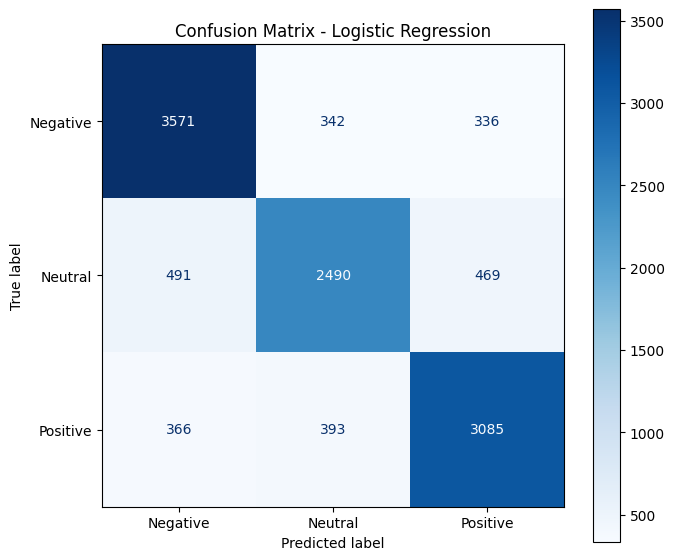

In [33]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Negative", "Neutral", "Positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [35]:
'''
The diagonal values represent correctly classified tweets:

Negative: 3,571 correctly classified
Neutral: 2,490 correctly classified
Positive: 3,085 correctly classified
'''

'\nThe diagonal values represent correctly classified tweets:\n\nNegative: 3,571 correctly classified\nNeutral: 2,490 correctly classified\nPositive: 3,085 correctly classified\n'

In [34]:
# Calculating the detailed metrics separately

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_test, y_pred, average="weighted"
)

recall = recall_score(
    y_test, y_pred, average="weighted"
)

f1 = f1_score(
    y_test, y_pred, average="weighted"
)

print("===== Overall Model Performance =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

===== Overall Model Performance =====
Accuracy : 0.7923
Precision: 0.7917
Recall   : 0.7923
F1-Score : 0.7916


In [36]:
# Final model summary

print("===== Task 2: Sentiment Analysis Summary =====")
print(f"Original dataset size: 74682")
print(f"Final dataset size: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"TF-IDF features: {X_train_tfidf.shape[1]}")
print("Model: Logistic Regression")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

===== Task 2: Sentiment Analysis Summary =====
Original dataset size: 74682
Final dataset size: 57714
Training samples: 46171
Testing samples: 11543
TF-IDF features: 10000
Model: Logistic Regression
Accuracy: 0.7923
Precision: 0.7917
Recall: 0.7923
F1-Score: 0.7916


In [37]:
# Saving the cleaned Dataset

cleaned_file = "Sentiment_Analysis_Cleaned.csv"

df.to_csv(cleaned_file, index=False)

print(f"Cleaned dataset saved as: {cleaned_file}")
print(f"Rows saved: {len(df)}")
print(f"Columns saved: {df.shape[1]}")

Cleaned dataset saved as: Sentiment_Analysis_Cleaned.csv
Rows saved: 57714
Columns saved: 5
